# Evaluación del modelo ConvNeXt-Tiny baseline

Este notebook tiene como objetivo evaluar el desempeño del modelo ConvNeXt-Tiny entrenado bajo el protocolo experimental definido. La evaluación se realiza utilizando el conjunto de prueba independiente del dataset MMOTU_OTU_2D_experimental.

## Configuración del entorno

Se configura el entorno de ejecución y se cargan los módulos desarrollados durante la etapa de entrenamiento.

In [1]:
from pathlib import Path
import sys
import torch


PROJECT_DIR = Path("../../../..").resolve()

if str(PROJECT_DIR) not in sys.path:
    sys.path.append(str(PROJECT_DIR))


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


print(PROJECT_DIR)
print(device)

/home/jvillanueva/projects/ovarian-tumor-ultrasound-classification
cuda


## Importación de componentes

In [2]:
from src.classification.transforms import (
    get_classification_transforms
)

from src.classification.dataset import (
    MMOTUClassificationDataset
)

from src.classification.dataloader import (
    create_dataloader
)

from src.classification.models import (
    create_convnext_tiny_classifier
)

from src.classification.evaluate import (
    predict,
    evaluate_predictions
)

## Preparación del conjunto de prueba

La evaluación final utiliza únicamente el conjunto test definido previamente.

In [3]:
DATA_DIR = (
    PROJECT_DIR /
    "data" /
    "processed" /
    "MMOTU_OTU_2D_experimental"
)


CSV_PATH = (
    PROJECT_DIR /
    "configs" /
    "splits" /
    "mmotu_experimental_split_standard.csv"
)

In [4]:
transform = get_classification_transforms()

test_dataset = MMOTUClassificationDataset(
    csv_file=CSV_PATH,
    image_dir=DATA_DIR,
    split="test",
    transform=transform
)

In [5]:
test_loader = create_dataloader(
    test_dataset,
    batch_size=32,
    shuffle=False
)


print(
    "Número de muestras test:",
    len(test_dataset)
)

Número de muestras test: 469


## Carga del modelo DenseNet121 entrenado

Se carga el checkpoint correspondiente al mejor modelo obtenido durante el entrenamiento.

In [6]:
MODEL_PATH = (
    PROJECT_DIR /
    "models" /
    "classification" /
    "convnext_tiny_baseline_best.pth"
)

In [7]:
model = create_convnext_tiny_classifier(
    pretrained=False,
    num_classes=2
)


model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)


model = model.to(device)

model.eval()

/tmp/ipykernel_250957/3246667349.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


ConvNeXt(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((96,), eps=1e-06, elementwise_affine=True)
    )
    (1): Sequential(
      (0): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=96, out_features=384, bias=True)
          (4): GELU(approximate='none')
          (5): Linear(in_features=384, out_features=96, bias=True)
          (6): Permute()
        )
        (stochastic_depth): StochasticDepth(p=0.0, mode=row)
      )
      (1): CNBlock(
        (block): Sequential(
          (0): Conv2d(96, 96, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=96)
          (1): Permute()
          (2): LayerNorm((96,), eps=1e-06, elementwise_affine=True)
          (3): Linear(in_features=

In [8]:
print(model.classifier)

Sequential(
  (0): LayerNorm2d((768,), eps=1e-06, elementwise_affine=True)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=768, out_features=2, bias=True)
)


## Generación de predicciones

La probabilidad de malignidad será utilizada para calcular métricas como ROC-AUC.

In [9]:
y_true, y_pred, y_prob = predict(
    model,
    test_loader,
    device
)


print(
    len(y_true),
    len(y_pred)
)

469 469


## Métricas de evaluación

Se calculan métricas adecuadas para conjuntos con distribución desbalanceada:

- Balanced Accuracy.
- ROC-AUC.
- Precision.
- Recall.
- F1-score.
- Matriz de confusión.

In [10]:
results = evaluate_predictions(y_true, y_pred, y_prob)

In [11]:
results["classification_report"]

'              precision    recall  f1-score   support\n\n      benign       0.96      0.66      0.78       421\n   malignant       0.20      0.77      0.32        48\n\n    accuracy                           0.67       469\n   macro avg       0.58      0.71      0.55       469\nweighted avg       0.88      0.67      0.73       469\n'

In [12]:
print(
    "Balanced Accuracy:",
    results["balanced_accuracy"]
)

print(
    "ROC-AUC:",
    results["roc_auc"]
)

Balanced Accuracy: 0.7132076405384007
ROC-AUC: 0.815568091844814


## Matriz de confusión

La matriz de confusión permite analizar los errores cometidos por el modelo, especialmente los falsos negativos correspondientes a muestras malignas clasificadas incorrectamente como benignas.

In [13]:
results["confusion_matrix"]

array([[276, 145],
       [ 11,  37]])

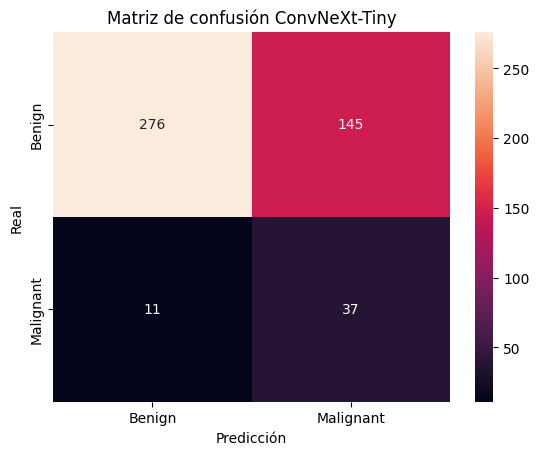

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


cm = results["confusion_matrix"]


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[
        "Benign",
        "Malignant"
    ],
    yticklabels=[
        "Benign",
        "Malignant"
    ]
)

plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de confusión ConvNeXt-Tiny")
plt.show()

## Almacenamiento de resultados experimentales

Los resultados obtenidos durante la evaluación son almacenados para mantener la trazabilidad del experimento y facilitar la comparación posterior con otras arquitecturas CNN.

In [15]:
import json

RESULT_DIR = (
    PROJECT_DIR /
    "results" /
    "classification" /
    "convnext_tiny_baseline"
)

RESULT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print(RESULT_DIR)

/home/jvillanueva/projects/ovarian-tumor-ultrasound-classification/results/classification/convnext_tiny_baseline


In [16]:
# Guardar métricas de evaluación
metrics = {
    "balanced_accuracy": results["balanced_accuracy"],
    "roc_auc": results["roc_auc"]
}

with open(
    RESULT_DIR / "metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=4
    )

In [17]:
# Guardar matriz de confusión
import pandas as pd


cm_df = pd.DataFrame(
    results["confusion_matrix"],
    index=[
        "Real_Benign",
        "Real_Malignant"
    ],
    columns=[
        "Pred_Benign",
        "Pred_Malignant"
    ]
)


cm_df.to_csv(
    RESULT_DIR /
    "confusion_matrix.csv"
)

In [18]:
# Guardar el reporte
with open(
    RESULT_DIR /
    "classification_report.txt",
    "w"
) as f:

    f.write(
        results["classification_report"]
    )

## Conclusión

El modelo obtuvo una exactitud global de 0.67. Sin embargo, debido al desbalance existente entre las clases, esta métrica debe interpretarse junto con métricas específicas por clase. En este sentido, ConvNeXt-Tiny alcanzó una Balanced Accuracy de 0.713 y un ROC-AUC de 0.816, evidenciando una mayor capacidad de discriminación entre clases respecto al comportamiento observado mediante la exactitud global.

Para la clase maligna, el modelo obtuvo un recall de 0.77, identificando correctamente 37 de las 48 muestras malignas presentes en el conjunto de prueba. No obstante, presentó una precisión de 0.20, debido a la clasificación incorrecta de 145 muestras benignas como malignas, lo que se refleja en la matriz de confusión mediante un elevado número de falsos positivos.

Estos resultados muestran que, bajo la configuración baseline evaluada, ConvNeXt-Tiny presenta una mayor sensibilidad para la detección de muestras malignas, aunque con un incremento en los errores de clasificación hacia la clase benigna. Este comportamiento evidencia el compromiso existente entre la sensibilidad y la precisión en escenarios con distribución desbalanceada.